In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [12]:
file_path = r'E:\Thesis\thesis_code\data\oscilloscope\ethernet_packets_1_2500.mat'

In [13]:
def load_ethernet_data(file_path, num_packets=10):
    """Loads metadata and a specific number of raw packets."""
    with h5py.File(file_path, 'r') as f:
        # Load metadata
        metadata = f['metadata']
        params = {
            'sample_rate': metadata['sample_rate'][0][0],
            'trigger_level': metadata['trigger_level'][0][0],
            'record_length': metadata['record_length'][0][0]
        }
        # Load only the first N packets to save memory
        packets = np.array(f['packets'][:num_packets, :])
    return packets, params

In [14]:
packets, params = load_ethernet_data(file_path)
print(f"Loaded {len(packets)} packets with parameters: {params}")

Loaded 10 packets with parameters: {'sample_rate': np.float64(1250000000.0), 'trigger_level': np.float64(-0.5), 'record_length': np.float64(250000.0)}


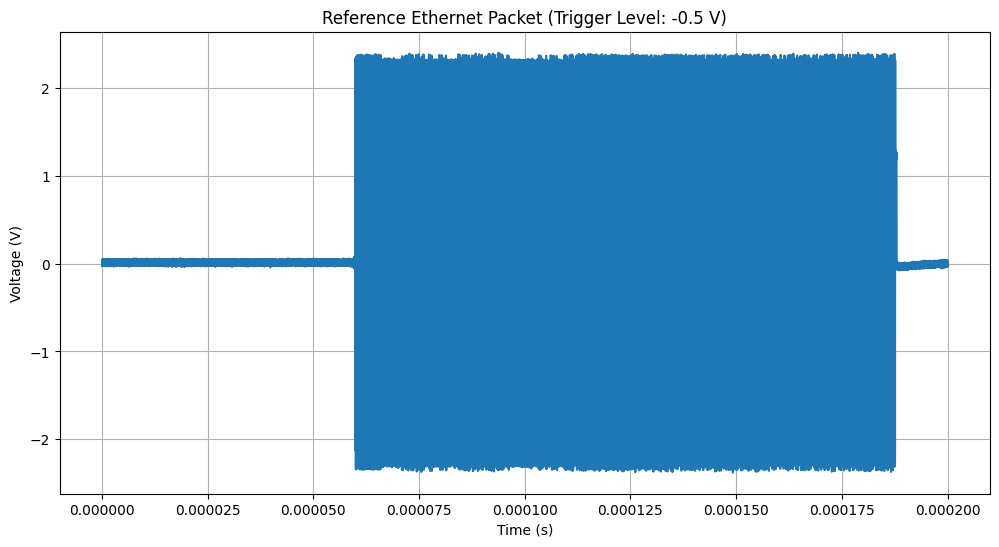

In [15]:
time_axis = np.arange(params['record_length']) / params['sample_rate']

plt.figure(figsize=(12,6))
plt.plot(time_axis, packets[4], label='Packet 1')  # Plot the first packet as an example
plt.title(f'Reference Ethernet Packet (Trigger Level: {params["trigger_level"]} V)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

In [16]:
def extract_signal_region(signal, threshold=0.1):
    """Trims the quiet parts of the signal before and after the packet."""
    active = np.abs(signal) > threshold
    indices = np.where(active)[0]
    if indices.size == 0:
        return np.array([])
    return signal[indices[0] : indices[-1] + 1]

In [17]:
def decode_to_bits(packet_signal, bit_distance=125, tolerance=20):
    """Converts raw voltage signal to a list of binary bits (0, 1)."""
    # DC offset removal and binarization
    signal_centered = packet_signal - np.mean(packet_signal)
    digital = (signal_centered > 0).astype(int)
    
    # Edge detection
    edges = np.where(np.diff(digital) != 0)[0]
    if len(edges) == 0: return []
    
    edge_distances = np.diff(edges)
    relevant_edges = [edges[0]]
    
    # Manchester edge recovery logic
    i = 0
    while i < len(edge_distances):
        if abs(edge_distances[i] - bit_distance) <= tolerance:
            relevant_edges.append(edges[i+1])
            i += 1
        elif i+1 < len(edge_distances) and abs(edge_distances[i] + edge_distances[i+1] - bit_distance) <= tolerance:
            relevant_edges.append(edges[i+2])
            i += 2
        else:
            i += 1

    # Bit assignment based on edge direction
    bits = []
    for e in relevant_edges:
        if e + 1 >= len(digital): break
        if digital[e] == 0 and digital[e+1] == 1:
            bits.append(1) # Rising
        elif digital[e] == 1 and digital[e+1] == 0:
            bits.append(0) # Falling
    return bits

In [18]:
def bits_to_bytes(bits, lsb_first=False):
    bytes_out = []
    for i in range(0, len(bits), 8):
        byte = 0
        chunk = bits[i:i+8]
        if len(chunk) < 8: break
        for j, bit in enumerate(chunk):
            if lsb_first:
                byte |= (bit << j)
            else:
                byte = (byte << 1) | bit
        bytes_out.append(byte)
    return bytes_out

def parse_ethernet_frame(bits):
    """Splits bitstream into Ethernet fields."""
    # Find SFD (Start Frame Delimiter: 10101011)
    pattern = [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,1]
    sfd_idx = None
    for i in range(len(bits) - 16):
        if bits[i:i+16] == pattern:
            sfd_idx = i + 16
            break
    
    if sfd_idx is None: return None
    print(f"SFD found at bit index: {sfd_idx}")

    return {
        "dest_mac": bits_to_bytes(bits[sfd_idx : sfd_idx+48]),
        "src_mac":  bits_to_bytes(bits[sfd_idx+48 : sfd_idx+96]),
        "eth_type": bits_to_bytes(bits[sfd_idx+96 : sfd_idx+112]),
        "payload":  bits_to_bytes(bits[sfd_idx+432 : -32], lsb_first=True),
        "crc":      bits_to_bytes(bits[-32:])
    }

In [ ]:
# --- Execution ---
file_path = r'E:\Thesis\thesis_code\data\oscilloscope\ethernet_packets_1_2500.mat'
raw_packets, params = load_ethernet_data(file_path, num_packets=10)

results = []

for idx in range(len(raw_packets)):
    # 1. Extraction
    signal = extract_signal_region(raw_packets[idx])
    
    # 2. Decoding
    bitstream = decode_to_bits(signal)
    
    # 3. Parsing
    frame = parse_ethernet_frame(bitstream)

    invalid_frame_count = 0
    
    if frame:
        results.append(frame)
        print(f"Packet {idx}: Decoded successfully. Payload Length: {len(frame['payload'])} bytes")
        print(f"Payload (hex): {' '.join('%02x' % b for b in frame['payload'][:16])} ...")  # Show first 16 bytes
    else:
        print(f"Packet {idx}: Could not find SFD pattern.")

# Example: View the first decoded Dest MAC
if results:
    print(f"\nExample Destination MAC (Packet 0): {['%02x' % b for b in results[0]['dest_mac']]}")

MemoryError: Unable to allocate 4.66 GiB for an array with shape (2500, 250000) and data type float64

In [20]:
len(results)  # Show first 5 decoded frames for inspection

96